# Online Shoppers Purchasing Intention Dataset

## Информация о переменных в датасете:

Набор данных состоит из 10 числовых и 8 категориальных атрибутов.

Атрибут "Revenue" может использоваться в качестве целевой переменной.

"Administrative", "Administrative Duration", "Informational", "Informational Duration", "Product Related" и "Product Related Duration" представляют собой количество различных типов страниц, посещенных посетителем во время данного сеанса, и общее время, проведенное в каждой из этих категорий страниц. Значения этих функций выводятся из информации URL-адресов страниц, посещенных пользователем, и обновляются в реальном времени, когда пользователь совершает какое-либо действие, например, переходит с одной страницы на другую.

Функции "Bounce Rate", "Exit Rate" и "Page Value" представляют собой метрики, измеряемые "Google Analytics" для каждой страницы на сайте электронной коммерции. Значение функции "Bounce Rate" для веб-страницы относится к проценту посетителей, которые заходят на сайт с этой страницы и затем покидают его ("отскакивают"), не инициируя никаких других запросов к серверу аналитики во время этого сеанса. Значение функции "Exit Rate" для конкретной веб-страницы рассчитывается как процент от всех просмотров этой страницы, которые были последними в сеансе. Функция "Page Value" представляет собой среднюю ценность веб-страницы, которую пользователь посетил перед завершением транзакции электронной коммерции.

Функция "Special Day" указывает на близость времени посещения сайта к определенному особому дню (например, Дню матери, Дню Святого Валентина), в который сеансы с большей вероятностью завершаются транзакцией. Значение этого атрибута определяется с учетом динамики электронной коммерции, такой как продолжительность между датой заказа и датой доставки. Например, для Дня Святого Валентина это значение принимает ненулевое значение в период со 2 по 12 февраля, нулевое значение до и после этой даты (если она не близка к другому особому дню) и достигает своего максимального значения 8 февраля, которое равно 1.

Набор данных также включает операционную систему, браузер, регион, тип трафика, тип посетителя (новый или вернувшийся), логическое значение, указывающее, является ли дата посещения выходным днем, а также месяц года.

### Импорт библиотек

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PURCHASING_DATASET = "/content/drive/MyDrive/EDA/online_shoppers_intention.csv"

In [ ]:
df = pd.read_csv(PURCHASING_DATASET)

### Структура данных:

In [ ]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


Есть 2 булевые и 2 текстовые переменные, посмотрим что может храниться в текстовых:

In [ ]:
df['Month'].unique()

array(['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep',
       'Dec'], dtype=object)

In [ ]:
df['VisitorType'].unique()

array(['Returning_Visitor', 'New_Visitor', 'Other'], dtype=object)

Проверяем на наличие дубликатов: (удаляем при наличии)

In [ ]:
print("Дубликаты:", df.duplicated().sum())

Дубликаты: 125


In [ ]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

Выводы:

*   Пропуски: Отсутствуют, это хорошо.
*   Дубликаты: Было 125 дублирующихся строк, которые мы удалили.

## Предобработка данных

Месяц - категориальный признак, не имеющий порядковой природы (нет, чтобы декабрь был больше января в контексте интернет-покупок). Использование One-Hot Encoding предотвращает появление ложных зависимостей, которые могли бы появиться при Label Encoding.

In [ ]:
one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
month_encoded = one_hot_encoder.fit_transform(df[['Month']])
month_df = pd.DataFrame(month_encoded, columns=one_hot_encoder.get_feature_names_out(['Month']))
df = pd.concat([df, month_df], axis=1)

In [ ]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Aug,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


VisitorType - имеет 3 категории: "New_Visitor", "Returning_Visitor", "Other"

Логично присвоить New_Visitor значение 0, а Returning_Visitor и Other — 1, чтобы модель могла уловить разницу между новым, вернувшимся и другими пользователями.

In [ ]:
visitor_map = {'New_Visitor': 0, 'Returning_Visitor': 1, 'Other': 1}
df['VisitorType_encoded'] = df['VisitorType'].map(visitor_map)
df['VisitorType_encoded']

,VisitorType_encoded
0,1
1,1
2,1
3,1
4,1
...,...
12200,1
12201,1
12202,1
12203,1


Weekend - бинарный признак, просто преобразуем True/False в 1/0.

In [ ]:
weekend_map = {False: 0, True: 1}
df['Weekend_encoded'] = df['Weekend'].map(weekend_map)
df['Weekend_encoded']

,Weekend_encoded
0,0
1,0
2,0
3,0
4,1
...,...
12200,1
12201,1
12202,1
12203,0


Revenue также преобразуем в бинарную.

In [ ]:
revenue_map = {False: 0, True: 1}
df['Revenue_encoded'] = df['Revenue'].map(revenue_map)
df['Revenue_encoded']

,Revenue_encoded
0,0
1,0
2,0
3,0
4,0
...,...
12200,0
12201,0
12202,0
12203,0


Удаление исходных категориальных столбцов

In [ ]:
df.drop(columns=['Month', 'VisitorType', 'Weekend', 'Revenue'], inplace=True)

In [ ]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_encoded,Weekend_encoded,Revenue_encoded
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0


## Корреляция

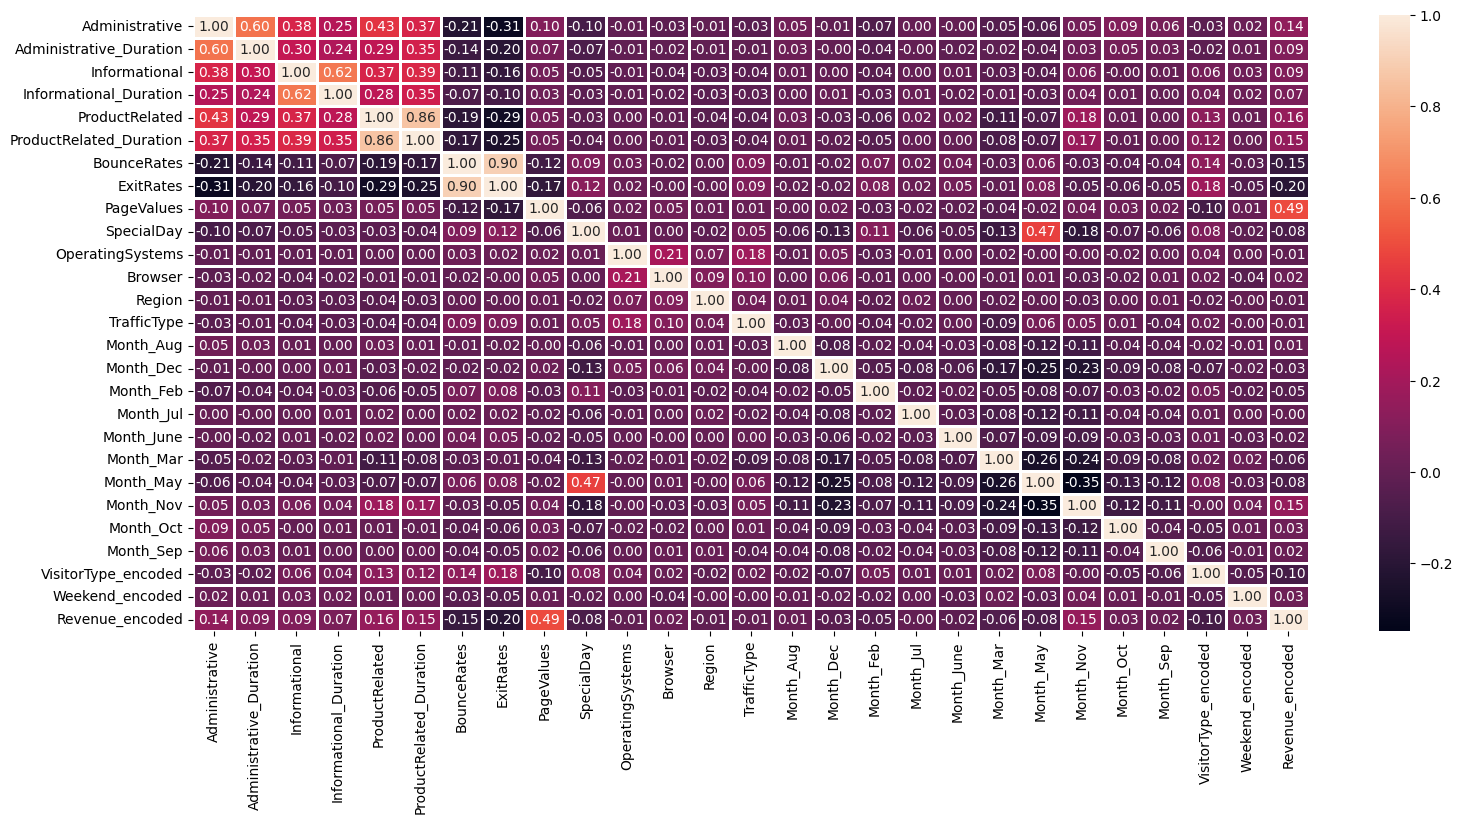

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(18,8))
sns.heatmap(corr, annot=True, fmt='.2f', linewidth=1)
plt.show()

Хорошо коррелирую те между собой атрибуты: Administrative, Administrative_Duration, Informational, Informational_Duration, ProductRelated, ProductRelated_Duration, BounceRates и ExitRates.

Рассмотрим целевую переменную Revenue:

In [ ]:
df['Revenue_encoded'].value_counts()

,count
Revenue_encoded,
0,10297
1,1908


И того false значений - 10297, true - 1908

Сбалансируем:

In [ ]:
df['Revenue_encoded'].value_counts()

,count
Revenue_encoded,
0,2000
1,1908


Посмотрим на корреляцию после балансировки

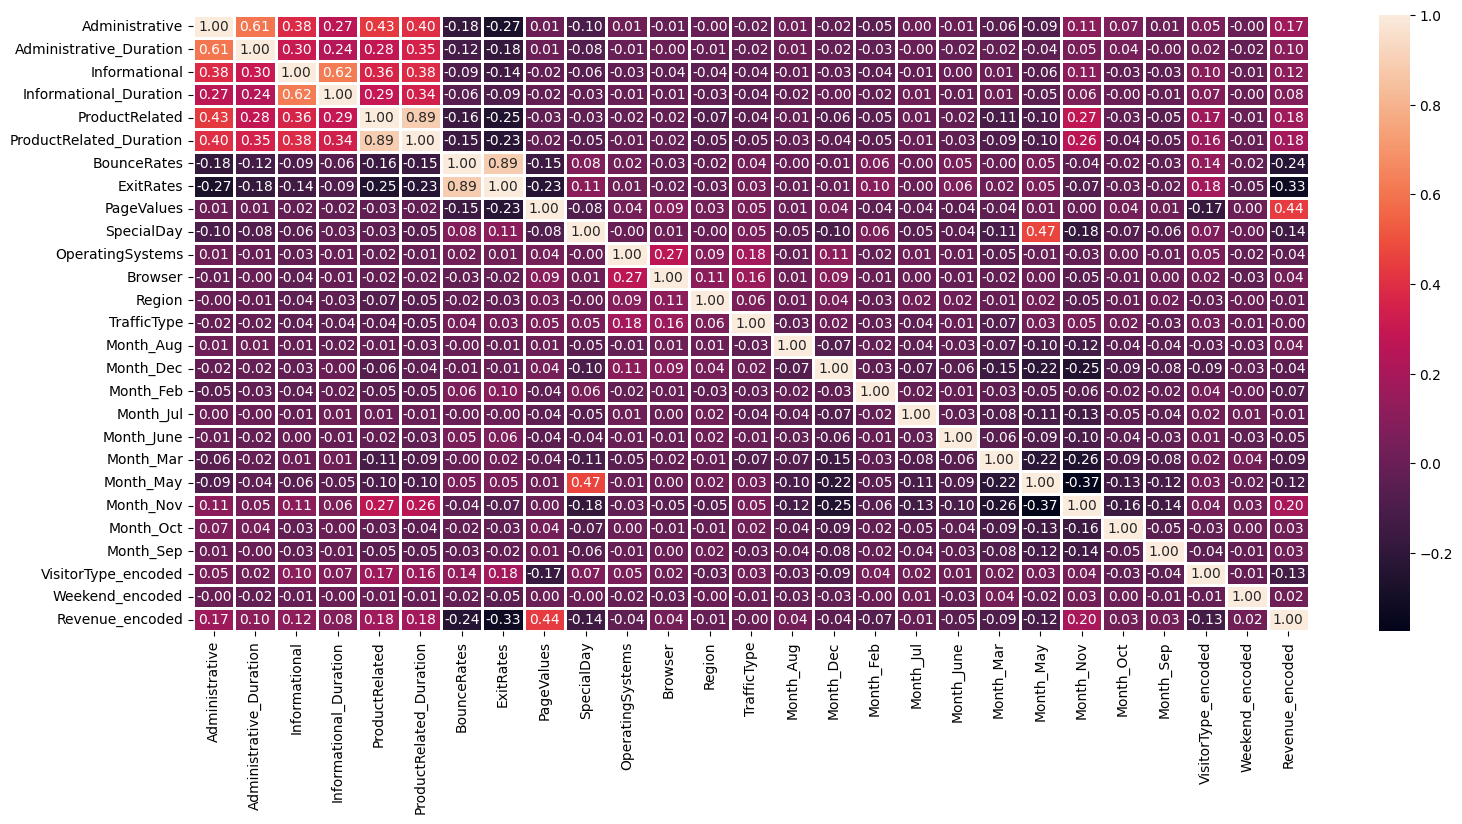

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(18,8))
sns.heatmap(corr, annot=True, fmt='.2f', linewidth=1)
plt.show()

Теперь корреляция с Revenue_encoded стала более явной

## Важность признаков

In [ ]:
X = df.drop(columns=['Revenue_encoded'])
y = df['Revenue_encoded']

### Random Forest

Выделяется PageValues

In [ ]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(n_estimators=100, random_state=43)
random_forest.fit(X, y)

feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': random_forest.feature_importances_
}).sort_values(by='Importance', ascending=False)
feature_importances

,Feature,Importance
8,PageValues,0.497401
5,ProductRelated_Duration,0.072815
7,ExitRates,0.062062
4,ProductRelated,0.051471
1,Administrative_Duration,0.047897
21,Month_Nov,0.047850
6,BounceRates,0.038095
0,Administrative,0.026808
13,TrafficType,0.024867
12,Region,0.022550


### Gradient Boosting

Выделяется PageValues

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting = GradientBoostingRegressor(n_estimators=100, random_state=42)
gradient_boosting.fit(X, y)

feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gradient_boosting.feature_importances_
}).sort_values(by='Importance', ascending=False)
feature_importances

,Feature,Importance
8,PageValues,0.747802
21,Month_Nov,0.071344
5,ProductRelated_Duration,0.038685
4,ProductRelated,0.022588
7,ExitRates,0.021363
1,Administrative_Duration,0.014903
20,Month_May,0.014266
0,Administrative,0.009678
3,Informational_Duration,0.009518
6,BounceRates,0.008223


### Permutation Importance

Выделяется PageValues

In [ ]:
from sklearn.inspection import permutation_importance

res = permutation_importance(random_forest, X, y, n_repeats=10, n_jobs=-1, random_state=35)

permutation_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': res['importances_mean']
}).sort_values(by='Importance', ascending=False)
permutation_importances

,Feature,Importance
8,PageValues,1.140992
21,Month_Nov,0.212607
5,ProductRelated_Duration,0.152608
7,ExitRates,0.137942
1,Administrative_Duration,0.117047
4,ProductRelated,0.109919
6,BounceRates,0.104998
0,Administrative,0.061222
13,TrafficType,0.040210
20,Month_May,0.034728


## Обучение моделей

Делим выборки на тренировочную и тестовую

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Random Forest:

In [85]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Обучаем модель
rf_model = RandomForestClassifier(n_estimators=150, max_depth=15, min_samples_split=5, min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Предсказания
y_pred_rf = rf_model.predict(X_test)

Оценка RF:

In [93]:
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_rf), 2))

              precision    recall  f1-score   support

           0       0.87      0.84      0.85       416
           1       0.82      0.86      0.84       366

    accuracy                           0.85       782
   macro avg       0.85      0.85      0.85       782
weighted avg       0.85      0.85      0.85       782

ROC-AUC: 0.85


Gradient Boosting:

In [89]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Обучаем модель
gb_model = GradientBoostingClassifier(n_estimators=120, learning_rate=0.05, max_depth=5, subsample=0.8, min_samples_split=5, random_state=42)
gb_model.fit(X_train, y_train)

# Предсказания
y_pred_gb = gb_model.predict(X_test)

Оценка GB:

In [92]:
print(classification_report(y_test, y_pred_gb))
print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_gb), 2))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85       416
           1       0.82      0.86      0.84       366

    accuracy                           0.84       782
   macro avg       0.84      0.84      0.84       782
weighted avg       0.84      0.84      0.84       782

ROC-AUC: 0.84


## Вывод

Обе модели показывают хорошие результаты.

RF показывает чуть лучшие результаты по всем метрикам, значит он чуть более устойчив на этих данных, поэтому лучше выбрать эту модель.

ROC-AUC у RF составила 85% у GB 84%, что является хорошими показателями, значит модели хорошо разделяют один класс от другого. (покупка/непокупка)